In [5]:
import os
import time
import random
import numpy as np
import pandas as pd 
import torch

from dataclasses import asdict
from itertools import product


In [ ]:
import sys
from pathlib import Path

project_root = Path("/Users/mansigoel/Documents/GitHub/Quantum-Machine-Learning-")
data_reupload_path = project_root / "data-re upload"

sys.path.append(str(data_reupload_path))
from models.LSTMAE_pipeline import (
    LSTMAEConfig,
    train_lstm_ae_latent_pipeline,
    plot_training_history,
    plot_reconstructed_series,
    plot_latent_trajectories,
)

In [6]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [7]:
base_lstm_config = LSTMAEConfig(
    value_col=4,

    # fixed for this tuning experiment
    window_size=20,
    latent_dim=6,
    train_window_end=350,

    # overwritten by grid search
    batch_size=16,
    learning_rate=0.001,

    # fixed
    n_epochs=1500,
    dropout_ratio=0.0,

    # rainfall fixed scaling
    scaler_type="fixed_range",
    scaler_feature_range=(-1.0, 1.0),
    fixed_min=0.0,
    fixed_max=400.0,
    clip_fixed_scaler=False,

    use_act=False,
    device="cpu",
    save_path=None,
    print_every=0,
)

In [8]:
ae_grid = {
    "learning_rate": [0.01, 0.05, 0.001, 0.005, 0.0001],
    "batch_size": [16, 32, 64]
}

In [9]:
def run_lstm_ae_grid_search(
    df_train: pd.DataFrame,
    base_config: LSTMAEConfig,
    ae_grid: dict,
    seed: int = 42,
    save_dir: str = "lstm_ae_tuning_results",
):
    os.makedirs(save_dir, exist_ok=True)

    results = []
    best_result = None
    best_val_loss = float("inf")

    keys = list(ae_grid.keys())
    values = list(ae_grid.values())

    total_runs = int(np.prod([len(v) for v in values]))
    run_id = 0

    for combo in product(*values):
        run_id += 1

        params = dict(zip(keys, combo))

        set_seed(seed)

        config_dict = asdict(base_config)

        for k, v in params.items():
            config_dict[k] = v

        run_name = (
            f"run_{run_id:03d}"
            f"_lr_{config_dict['learning_rate']}"
            f"_bs_{config_dict['batch_size']}"
            f"_latent_{config_dict['latent_dim']}"
            f"_win_{config_dict['window_size']}"
        )

        save_path = os.path.join(save_dir, f"{run_name}.pth")
        config_dict["save_path"] = save_path

        config = LSTMAEConfig(**config_dict)

        print("=" * 80)
        print(f"Run {run_id}/{total_runs}")
        print("Params:", params)
        print("Save path:", save_path)

        start_time = time.time()

        lstm_results = train_lstm_ae_latent_pipeline(
            df=df_train,
            config=config,
            fit_scaler_in_train=True,
        )

        elapsed_time = time.time() - start_time

        history = lstm_results["history"]

        final_train_loss = history["train_loss"][-1]
        final_val_loss = history["val_loss"][-1]
        best_run_val_loss = history["best_val_loss"]

        row = {
            "run_id": run_id,
            "run_name": run_name,
            "seed": seed,

            "window_size": config.window_size,
            "latent_dim": config.latent_dim,
            "train_window_end": config.train_window_end,

            "learning_rate": config.learning_rate,
            "batch_size": config.batch_size,
            "n_epochs": config.n_epochs,
            "dropout_ratio": config.dropout_ratio,

            "scaler_type": config.scaler_type,
            "fixed_min": config.fixed_min,
            "fixed_max": config.fixed_max,
            "clip_fixed_scaler": config.clip_fixed_scaler,

            "final_train_loss": final_train_loss,
            "final_val_loss": final_val_loss,
            "best_val_loss": best_run_val_loss,

            "elapsed_time_sec": elapsed_time,
            "save_path": save_path,
        }

        results.append(row)

        print(f"Final train loss: {final_train_loss:.6f}")
        print(f"Final val loss:   {final_val_loss:.6f}")
        print(f"Best val loss:    {best_run_val_loss:.6f}")
        print(f"Time:             {elapsed_time:.2f} sec")

        if best_run_val_loss < best_val_loss:
            best_val_loss = best_run_val_loss
            best_result = {
                "row": row,
                "lstm_results": lstm_results,
            }

            print("New best model found.")

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("best_val_loss").reset_index(drop=True)

    csv_path = os.path.join(save_dir, "lstm_ae_grid_search_results.csv")
    results_df.to_csv(csv_path, index=False)

    print("=" * 80)
    print("Grid search complete.")
    print("Best validation loss:", best_val_loss)
    print("Results saved to:", csv_path)

    return results_df, best_result

In [12]:
from pathlib import Path
import pandas as pd

project_root = Path("/Users/mansigoel/Documents/GitHub/Quantum-Machine-Learning-")

file_path = project_root / "SPEI_AllScales_Napak - SPEI_AllScales_Napak.csv"

print(file_path.exists())
print(file_path)

df = pd.read_csv(file_path)

train_end_idx = 434

df_train = df.iloc[:train_end_idx].copy()
df_test = df.iloc[train_end_idx:].copy()

print("df_train shape:", df_train.shape)
print("df_test shape:", df_test.shape)

True
/Users/mansigoel/Documents/GitHub/Quantum-Machine-Learning-/SPEI_AllScales_Napak - SPEI_AllScales_Napak.csv
df_train shape: (434, 17)
df_test shape: (105, 17)


In [13]:
results_df, best_ae_result = run_lstm_ae_grid_search(
    df_train=df_train,
    base_config=base_lstm_config,
    ae_grid=ae_grid,
    seed=42,
    save_dir="lstm_ae_tuning_latent6_window20",
)

Run 1/15
Params: {'learning_rate': 0.01, 'batch_size': 16}
Save path: lstm_ae_tuning_latent6_window20/run_001_lr_0.01_bs_16_latent_6_win_20.pth
Final train loss: 0.025254
Final val loss:   0.048245
Best val loss:    0.044023
Time:             110.83 sec
New best model found.
Run 2/15
Params: {'learning_rate': 0.01, 'batch_size': 32}
Save path: lstm_ae_tuning_latent6_window20/run_002_lr_0.01_bs_32_latent_6_win_20.pth
Final train loss: 0.026493
Final val loss:   0.049100
Best val loss:    0.045779
Time:             54.30 sec
Run 3/15
Params: {'learning_rate': 0.01, 'batch_size': 64}
Save path: lstm_ae_tuning_latent6_window20/run_003_lr_0.01_bs_64_latent_6_win_20.pth
Final train loss: 0.026933
Final val loss:   0.049179
Best val loss:    0.045222
Time:             38.19 sec
Run 4/15
Params: {'learning_rate': 0.05, 'batch_size': 16}
Save path: lstm_ae_tuning_latent6_window20/run_004_lr_0.05_bs_16_latent_6_win_20.pth
Final train loss: 0.108161
Final val loss:   0.119666
Best val loss:    0.

In [14]:
results_df[[
    "run_id",
    "learning_rate",
    "batch_size",
    "best_val_loss",
    "final_train_loss",
    "final_val_loss",
    "elapsed_time_sec",
    "save_path",
]]

,run_id,learning_rate,batch_size,best_val_loss,final_train_loss,final_val_loss,elapsed_time_sec,save_path
0,1,0.0100,16,0.044023,0.025254,0.048245,110.827487,lstm_ae_tuning_latent6_window20/run_001_lr_0.0...
1,4,0.0500,16,0.045219,0.108161,0.119666,98.762809,lstm_ae_tuning_latent6_window20/run_004_lr_0.0...
2,3,0.0100,64,0.045222,0.026933,0.049179,38.188208,lstm_ae_tuning_latent6_window20/run_003_lr_0.0...
3,2,0.0100,32,0.045779,0.026493,0.049100,54.303656,lstm_ae_tuning_latent6_window20/run_002_lr_0.0...
4,8,0.0010,32,0.045792,0.037195,0.046256,57.532142,lstm_ae_tuning_latent6_window20/run_008_lr_0.0...
5,11,0.0050,32,0.045950,0.030528,0.046290,56.716960,lstm_ae_tuning_latent6_window20/run_011_lr_0.0...
6,7,0.0010,16,0.046142,0.032491,0.047007,98.641279,lstm_ae_tuning_latent6_window20/run_007_lr_0.0...
7,10,0.0050,16,0.046159,0.028155,0.048161,96.615078,lstm_ae_tuning_latent6_window20/run_010_lr_0.0...
8,6,0.0500,64,0.046413,0.028179,0.056627,39.044107,lstm_ae_tuning_latent6_window20/run_006_lr_0.0...
9,5,0.0500,32,0.046563,0.029141,0.050416,54.088076,lstm_ae_tuning_latent6_window20/run_005_lr_0.0...


In [15]:
best_row = results_df.iloc[0]
best_lstm_results = best_ae_result["lstm_results"]

print(best_row)

run_id                                                               1
run_name                         run_001_lr_0.01_bs_16_latent_6_win_20
seed                                                                42
window_size                                                         20
latent_dim                                                           6
train_window_end                                                   350
learning_rate                                                     0.01
batch_size                                                          16
n_epochs                                                          1500
dropout_ratio                                                      0.0
scaler_type                                                fixed_range
fixed_min                                                          0.0
fixed_max                                                        400.0
clip_fixed_scaler                                                False
final_

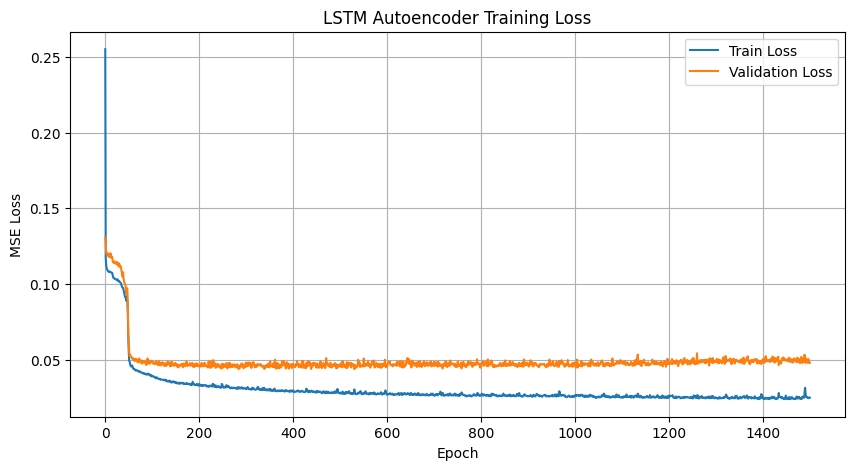

In [16]:
plot_training_history(best_lstm_results["history"])

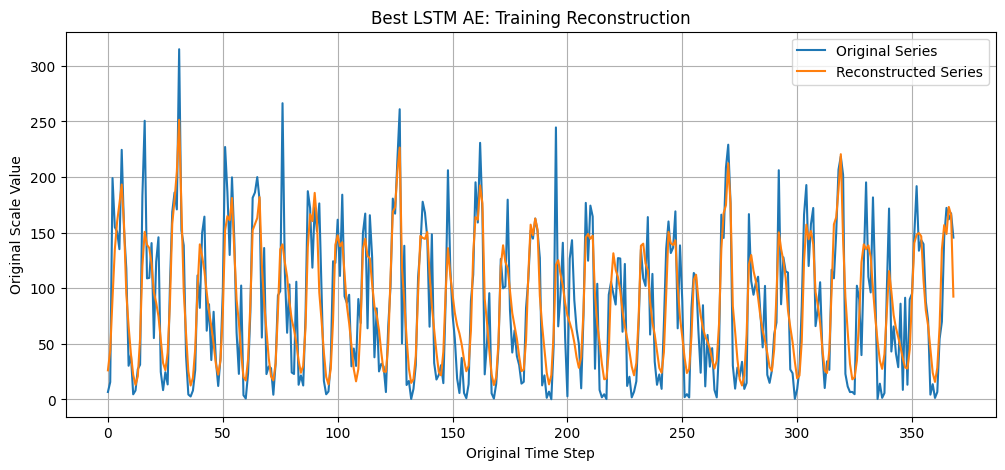

In [17]:
plot_reconstructed_series(
    original_windows=best_lstm_results["X_train"],
    reconstructed_windows=best_lstm_results["X_train_reconstructed"],
    scaler=best_lstm_results["scaler"],
    title="Best LSTM AE: Training Reconstruction",
)

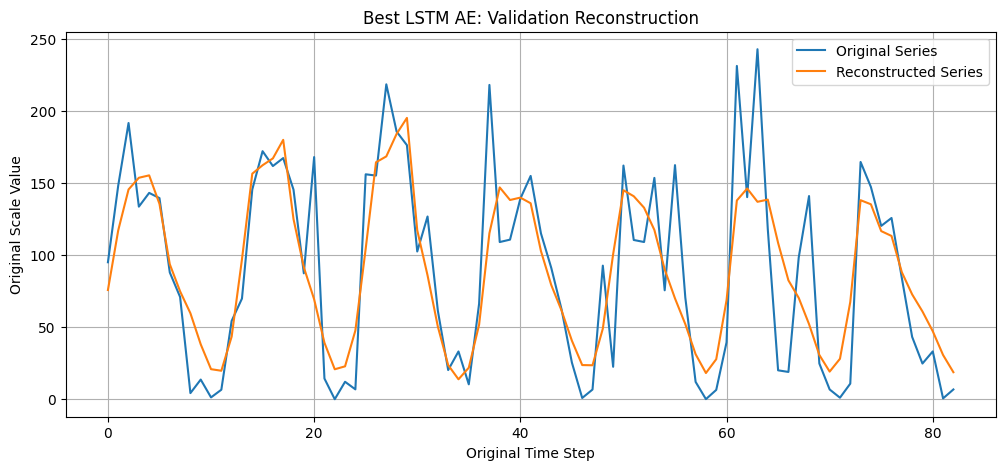

In [18]:
plot_reconstructed_series(
    original_windows=best_lstm_results["X_val"],
    reconstructed_windows=best_lstm_results["X_val_reconstructed"],
    scaler=best_lstm_results["scaler"],
    title="Best LSTM AE: Validation Reconstruction",
)